# Simulations module

One way to validate a $\mathrm{H^{2}MM}$  model is to run a Monte-Carlo simulation.
Here, the photon times are retained, and the model is used as a basis to
create a Monte-Carlo state-path, and that statepath to further Monte-Carlo simulate a new set of detectors.

Since the model is stochastic, it is unlikely the value of single bursts will match, 
but the overal distribution of ratiometric paramters should be reproduced.

This simulation can be done with the `bhm.H2MMSim` class.

Before we begin, let's load some example data sets:

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tables as tb
import smfbursts as smf

import H2MMbursts as bhm

raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)


raw_hp3 = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data_hp3 = smf.photonHDF5.regularize_dets(raw_hp3)
data_hp3.irf_thresh[smf.PhSel('0ex0em')] = 2350

data_yop = smf.loadraw.load_dir('data/Apo_50us ALEX_1hr/')


# load saved optimized params
import os
statepathfile = 'data/statepathparams.hdf5'
if os.path.exists(statepathfile):
    with tb.open_file('data/statepathparams.hdf5', 'r') as f:
        statepaths_hp3 = [smf.Param.decode_group(g) for g in
                          f.list_nodes(f.root.HP3_TE300_SPC630.statepath_params)]
        statepaths_yop = [smf.Param.decode_group(g) for g in
                           f.list_nodes(f.root.Yopo_Apo.statepath_params)]
    
    brsts_hp3 = statepaths_hp3[0].base_param
    brsts_yop = statepaths_yop[0].base_param
else:
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))

    # optimize streams data
    dbs_hp3 = smf.fretfactory.make_bg(data_hp3, period=60.0, tail_min=5e-4,
                                     auto_threshold=True,
                                     func=smf.bg.exp_mlefit, F_bg=1.7)
    smf.fretfactory.make_burst_search(bg=dbs_hp3['bg'], m=10, F=6.0,
                                      update=dbs_hp3)
    gate_Allhp3 = smf.make_geq_gate(dbs_hp3['NphDex_raw'], 50)
    gate_Allhp3 = gate_Allhp3 & smf.make_geq_gate(dbs_hp3['NphAA_raw'], 25)
    smf.fretfactory.apply_gate(dbs_hp3, gate_Allhp3)
    brsts_hp3 = dbs_hp3['bursts']
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
    statepaths_hp3 = bhm.StatePath.optimize_models(
        data_hp3, brsts_hp3, streams=streams, max_states=8,
        min_states=1, to_state=4, conv_crit='BICph')
    
    # optimize multiparameter usAlex data
    dbs_yop = smf.fretfactory.make_bg(data_yop, period=60.0, F_bg=1.7,
                                      func=smf.bg.exp_mlefit,
                                      tail_min=5e-4, auto_threshold=True)
    smf.fretfactory.make_burst_search(bg=dbs_yop['bg'], m=10, F=6.0, 
                                      streams=smf.PhSel('0ex_1ex1em'),
                                      update=dbs_yop, nbva=5)
    gate_Allyop = smf.make_geq_gate(dbs_yop['NphDex_raw'], 50)
    gate_Allyop = gate_Allyop & smf.make_geq_gate(dbs_yop['NphAA_raw'], 30)
    gate_FRETyop = gate_Allyop& smf.make_range_gate(dbs_yop['S_bg'], 0.25, 0.7)
    smf.fretfactory.apply_gate(dbs_yop, gate_FRETyop)
    shifts = ('base', 'base', 'neven:0')
    statepaths_yop = bhm.usAlexStatePath.optimize_models(
        data_yop, dbs_yop['bursts'], streams=streams, shifts=shifts, 
        conv_crit='BICph', thresh=0.005)

## Monte Carlo recoloring

Simulations, executed by the `bhm.sim.H2MMSim` are Monte-Carlo 
recolored state and index versions of `bhm.StatePath`.
The photon times are retained, but other parameters are simulated.

Therefore the params and parents are the same as `bhm.StatePath`, with the addition of the "seed" param.
This is an integer random number generator seed, this way simulations can be recreated.

The `bhm.StatePathSim` has the same columns as a `smf.photondata.BasePhotonTable`, 
it can take the place of a `smf.photondata.BasePhotonTable` in many cases,
but it is not actually such a base table.
This is because the start/stop times are borrowed from the parent.
So a `bhm.StatePathSim` based `smf.Param` will have a `smf.Param.base_param`
that is it's parent ("bursts").

(<matplotlib.collections.PathCollection at 0x7e4c4299a4b0>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

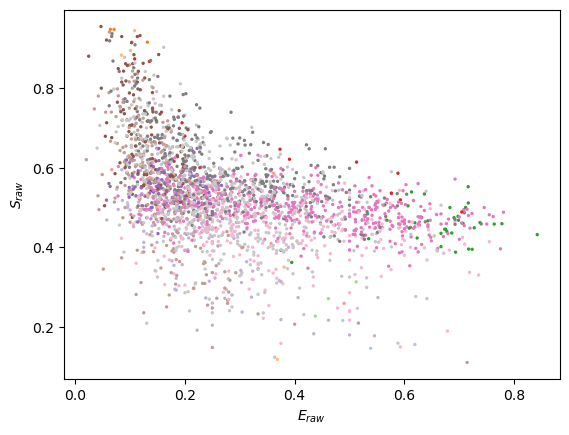

In [2]:
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
model = statepaths_hp3[3].model

sim = smf.Param(bhm.sim.H2MMSim, 
                params={'streams':streams, 'model':model, 'seed':23},
                parents={'bursts':brsts_hp3})

simE_raw = smf.Column(sim, 'E_raw')
simS_raw = smf.Column(sim, 'S_raw')
simBstate = smf.Column(sim, 'bstates')

smf.plot.scatter(data_hp3, simE_raw, simS_raw, s=2.0,
                 point_func=smf.plot.colorcategory,
                 point_cols=simBstate, point_kwargs={'cmap':'tab20'})

### `bhm.simulations.SimDwells` class

Because the recoloring is internal to the `bhm.sim.H2MMSim`,
to assess the dwells, instead of using `bhm.Dwells`, it is required to
use `bhm.sim.SimDwells` instead, which will compute the nph, ratio etc. columns from the simulated, 
and not the original photons.

(<matplotlib.collections.PathCollection at 0x7e4c4bd36900>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

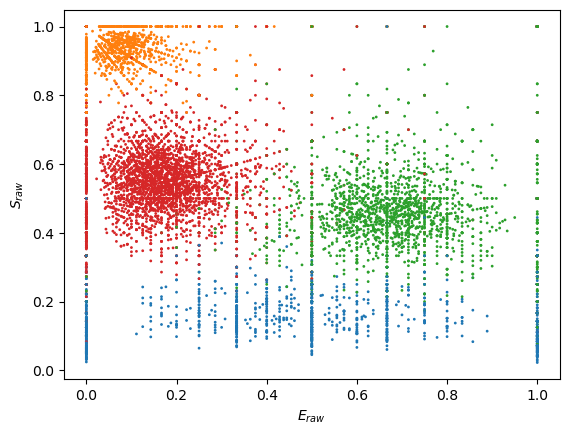

In [3]:
sdwell = smf.Param(bhm.sim.SimDwells, parents={'statepath':sim})

sdEraw = smf.Column(sdwell, 'E_raw')
sdSraw = smf.Column(sdwell, 'S_raw')
sdState = smf.Column(sdwell, "state")

smf.plot.scatter(data_hp3, sdEraw, sdSraw,
                 point_func=smf.plot.colorcategory,
                 point_cols=sdState, point_kwargs={'cmap':'tab10'},
                 s=1.0)

## Other simulations

Finally, it should be noted that 
- `bhm.usAlexStatePath` can be simulated in an analagous way with `bhm.sim.usAlexH2MMSim`
- `bhm.ntdivStatePath` can be simulated in an analagous way with `bhm.sim.ntdivH2MMSim`

(<matplotlib.collections.PathCollection at 0x7e4c4bd9a270>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

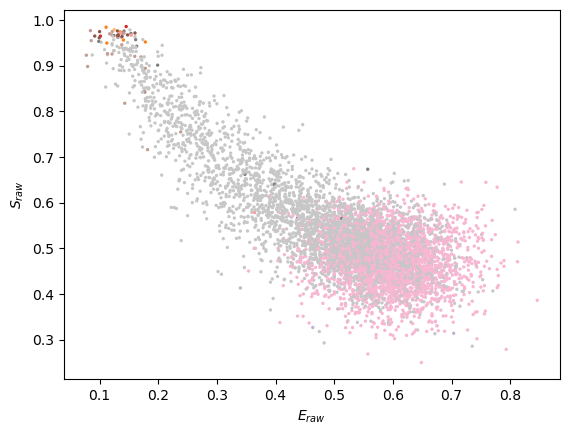

In [4]:
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
shifts = ('base', 'base', 'neven:0')
model = statepaths_yop[3].model

ussim = smf.Param(bhm.sim.usAlexH2MMSim, 
                  params={'streams':streams, 'model':model, 
                          'shifts':shifts, 'seed':31},
                  parents={'bursts':brsts_hp3})

ussimE_raw = smf.Column(ussim, 'E_raw')
ussimS_raw = smf.Column(ussim, 'S_raw')
ussimBstate = smf.Column(ussim, 'bstates')

smf.plot.scatter(data_yop, ussimE_raw, ussimS_raw, s=2.0,
                 point_func=smf.plot.colorcategory,
                 point_cols=ussimBstate, point_kwargs={'cmap':'tab20'})

In [5]:
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
divs = (np.array([2500, 3000]), np.array([], dtype=np.int64), np.array([500,]))
ntmodel = bhm.factory_h2mm_model(4, 6)

statepathsnt_hp3 = bhm.ntdivStatePath.optimize_models(
    data_hp3, brsts_hp3, streams=streams, divs=divs, 
)

The model converged after 2 iterations
The model converged after 87 iterations
The model converged after 171 iterations
The model converged after 187 iterations
Optimization reached maximum number of iterations


An example with `bhm.sim.ntdivH2MMSim`:

(<matplotlib.collections.PathCollection at 0x7e4c427558e0>,
 Text(0.5, 0, '$E_{raw}$'),
 Text(0, 0.5, '$S_{raw}$'))

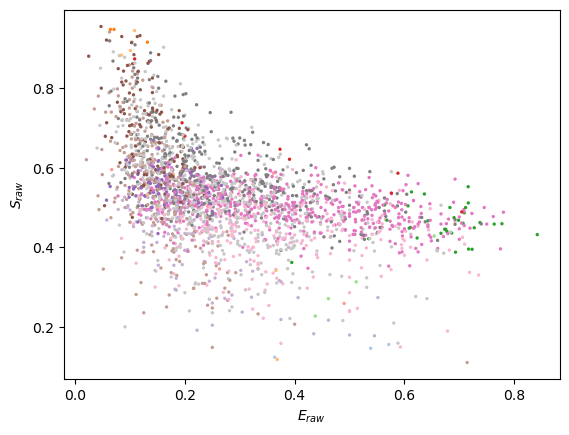

In [6]:
ntmodel = statepathsnt_hp3[3].params['model']

ntsim = smf.Param(bhm.sim.ntdivH2MMSim, 
                params={'streams':streams, 'divs':divs, 
                        'model':ntmodel, 'seed':23},
                parents={'bursts':brsts_hp3})

ntsimE_raw = smf.Column(ntsim, 'E_raw')
ntsimS_raw = smf.Column(ntsim, 'S_raw')
ntsimBstate = smf.Column(ntsim, 'bstates')

smf.plot.scatter(data_hp3, ntsimE_raw, ntsimS_raw, s=2.0,
                 point_func=smf.plot.colorcategory,
                 point_cols=ntsimBstate, point_kwargs={'cmap':'tab20'})

This concludes the module tutorial.